In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Demographic analysis") \
    .config("spark.sql.legacy.allowUntypedScalaUDF", "true") \
    .getOrCreate()

df_pusa = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("/datasets/demographics/psam_pusa.csv")

df_pusb = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("/datasets/demographics/psam_pusb.csv")

df_demo = df_pusa.unionByName(df_pusb)

print("Rows:", df_demo.count())
df_demo.printSchema()


Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/01 09:51:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[Stage 4:======================================================>  (23 + 1) / 24]

Rows: 3373378
root
 |-- RT: string (nullable = true)
 |-- SERIALNO: string (nullable = true)
 |-- DIVISION: integer (nullable = true)
 |-- SPORDER: integer (nullable = true)
 |-- PUMA: integer (nullable = true)
 |-- REGION: integer (nullable = true)
 |-- ST: integer (nullable = true)
 |-- ADJINC: integer (nullable = true)
 |-- PWGTP: integer (nullable = true)
 |-- AGEP: integer (nullable = true)
 |-- CIT: integer (nullable = true)
 |-- CITWP: integer (nullable = true)
 |-- COW: integer (nullable = true)
 |-- DDRS: integer (nullable = true)
 |-- DEAR: integer (nullable = true)
 |-- DEYE: integer (nullable = true)
 |-- DOUT: integer (nullable = true)
 |-- DPHY: integer (nullable = true)
 |-- DRAT: integer (nullable = true)
 |-- DRATX: integer (nullable = true)
 |-- DREM: integer (nullable = true)
 |-- ENG: integer (nullable = true)
 |-- FER: integer (nullable = true)
 |-- GCL: integer (nullable = true)
 |-- GCM: integer (nullable = true)
 |-- GCR: integer (nullable = true)
 |-- HIMRKS: i

In [3]:
from pyspark.sql import functions as F
missing_raw = df_demo.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_demo.columns
]).toPandas()

missing_raw.T.sort_values(by=0, ascending=False).head(20)

25/12/01 09:52:37 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
/usr/local/lib/python3.9/site-packages/pyspark/sql/pandas/conversion.py:202: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[column_name] = series
/usr/local/lib/python3.9/site-packages/pyspark/sql/pandas/conversion.py:202: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[column_name] = series
/usr/local/lib/python3.9/site-packages/pyspark/sql/pandas/

,0
GCM,3351901
DRAT,3316565
GCR,3306618
SFR,3278082
SFN,3278082
FOD2P,3271654
FHINS5C,3258338
MLPJ,3167535
VPS,3167535
MLPE,3167535


In [4]:
from pyspark.sql import functions as F

features = [
    "AGEP", "SEX", "SCHL", "MAR", "RAC1P", "NATIVITY",
    "ESR", "WKHP", "WKWN", "WAGP", "OCCP", "INDP",
    "HICOV", "POVPIP",
    "HINS1","HINS2","HINS3","HINS4","HINS5","HINS6","HINS7"
]

n = df_demo.count()

missing_pct = df_demo.select([
    (F.sum(F.col(c).isNull().cast("int")) / n * 100).alias(c)
    for c in ["PINCP"] + features
]).toPandas().T

missing_pct.columns = ["missing_pct"]
missing_pct = missing_pct.sort_values("missing_pct", ascending=False)

missing_pct

,missing_pct
WKHP,48.696203
WKWN,48.696203
OCCP,40.500649
INDP,40.500649
ESR,16.718790
PINCP,15.500071
WAGP,15.500071
POVPIP,4.546066
SCHL,2.686358
AGEP,0.000000


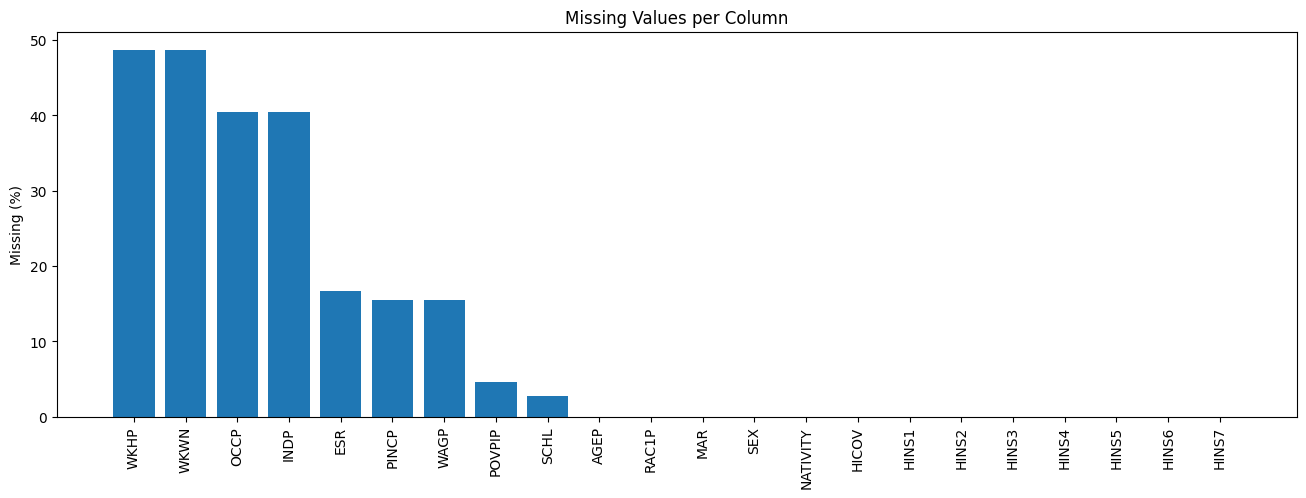

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))
plt.bar(missing_pct.index, missing_pct["missing_pct"])
plt.xticks(rotation=90)
plt.ylabel("Missing (%)")
plt.title("Missing Values per Column")
plt.show()

In [6]:
features = [
    "AGEP", "SEX", "SCHL", "MAR", "RAC1P", "NATIVITY",
    "ESR", "WKHP", "WKWN", "WAGP", "OCCP", "INDP",
    "HICOV", "POVPIP",
    "HINS1", "HINS2", "HINS3", "HINS4", "HINS5", "HINS6", "HINS7"
]

df = df_demo.select(["PINCP"] + features).dropna()

In [7]:
numeric_cols = ["PINCP", "AGEP", "WKHP", "WKWN", "WAGP", "POVPIP"]
df_num = df.select(numeric_cols).dropna()
pdf = df_num.toPandas()

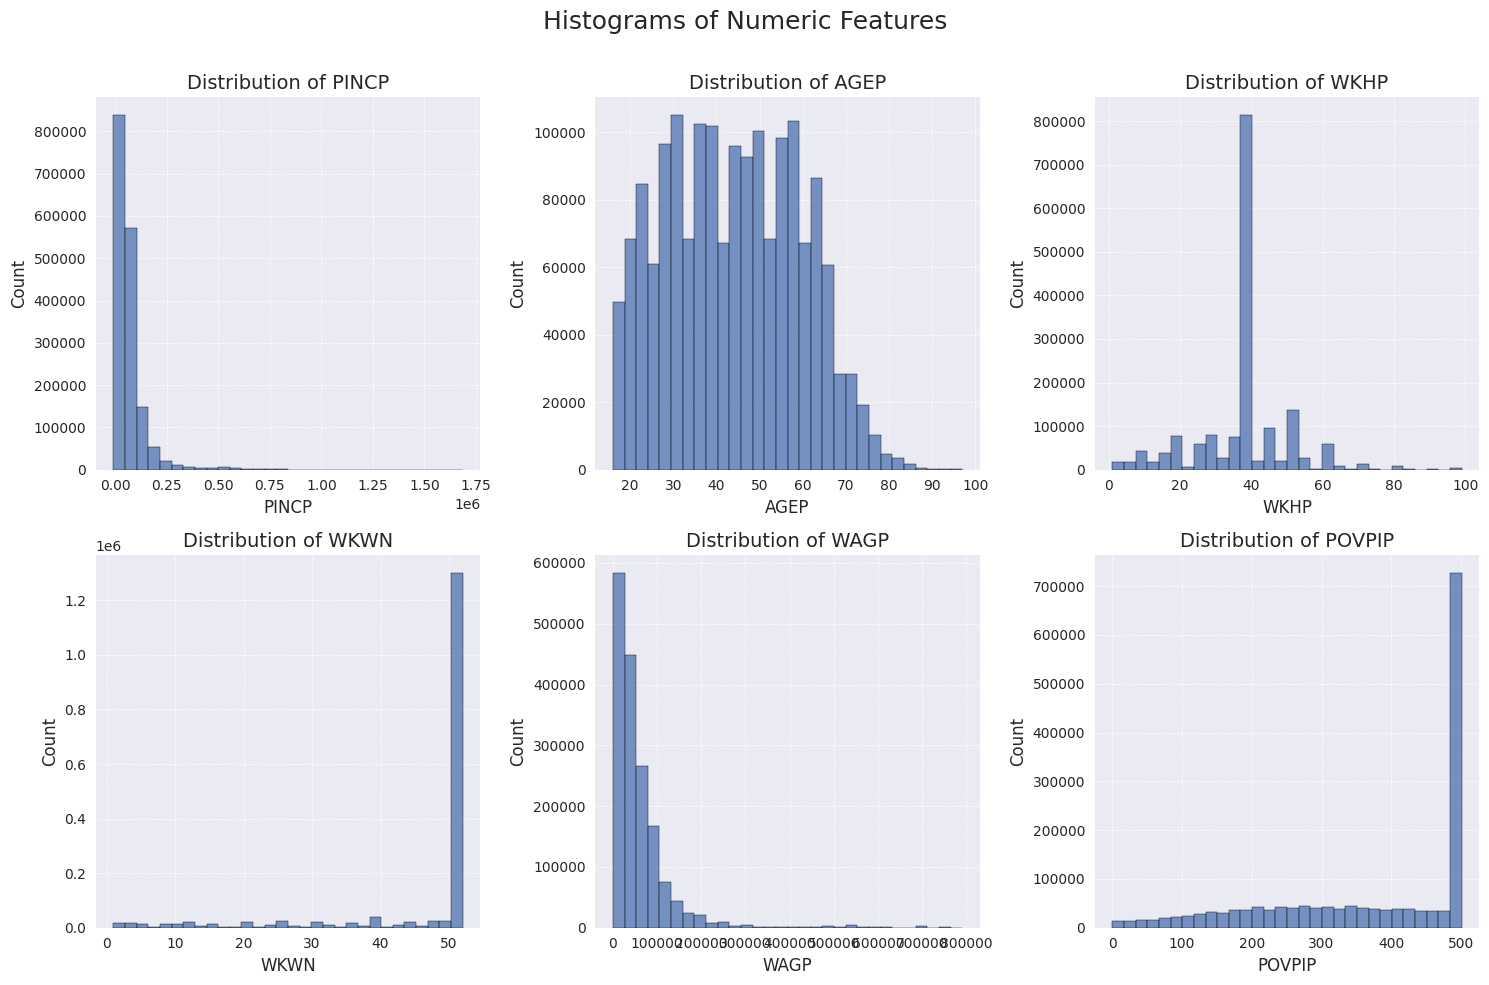

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

num_cols = numeric_cols

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(pdf[col], bins=30, kde=False, ax=ax, edgecolor="black")
    
    ax.set_title(f"Distribution of {col}", fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.grid(True, linestyle="--", linewidth=0.5)

plt.suptitle("Histograms of Numeric Features", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

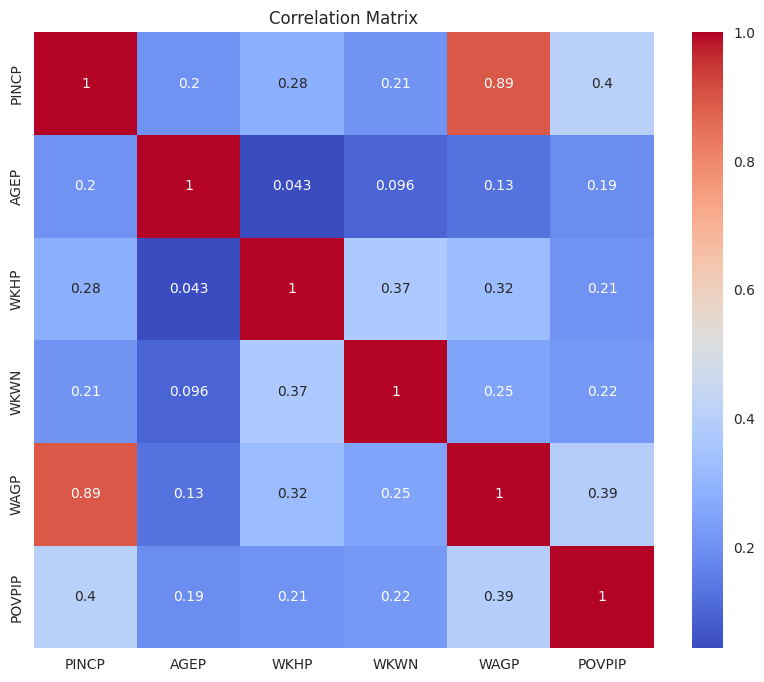

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ["PINCP", "AGEP", "WKHP", "WKWN", "WAGP", "POVPIP"]

pdf = df.select(numeric_cols).dropna().sample(fraction=0.05).toPandas()
plt.figure(figsize=(10, 8))
sns.heatmap(pdf.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


Rows after sampling: 134841


25/12/01 09:57:57 WARN Instrumentation: [4c271c5f] regParam is zero, which might cause numerical instability and overfitting.
25/12/01 09:58:05 WARN InstanceBuilder$NativeBLAS: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/12/01 09:58:05 WARN InstanceBuilder$NativeBLAS: Failed to load implementation from:dev.ludovic.netlib.blas.ForeignLinkerBLAS
25/12/01 09:58:12 WARN InstanceBuilder$NativeLAPACK: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
25/12/01 10:03:29 WARN DAGScheduler: Broadcasting large task binary with size 1015.5 KiB
25/12/01 10:03:30 WARN DAGScheduler: Broadcasting large task binary with size 1021.9 KiB
25/12/01 10:03:30 WARN DAGScheduler: Broadcasting large task binary with size 1022.3 KiB
25/12/01 10:03:31 WARN DAGScheduler: Broadcasting large task binary with size 1022.9 KiB
25/12/01 10:03:31 WARN DAGScheduler: Broadcasting large task binary with size 1024.4 KiB
25/12/01 10:03:31 WARN DAGScheduler: Broadcasting large tas

               Model   RMSE(train)    RMSE(test)    MAE(train)     MAE(test)  \
0  Linear Regression  74176.286285  75665.052326  38766.264348  39136.141734   
1      Decision Tree  60737.893969  70187.291703  26943.866870  30583.977545   
2                GBT  59943.498897  68280.429757  27319.777239  30290.409618   

   R2(train)  R2(test)  
0   0.242008  0.237116  
1   0.491777  0.343576  
2   0.504984  0.378759  


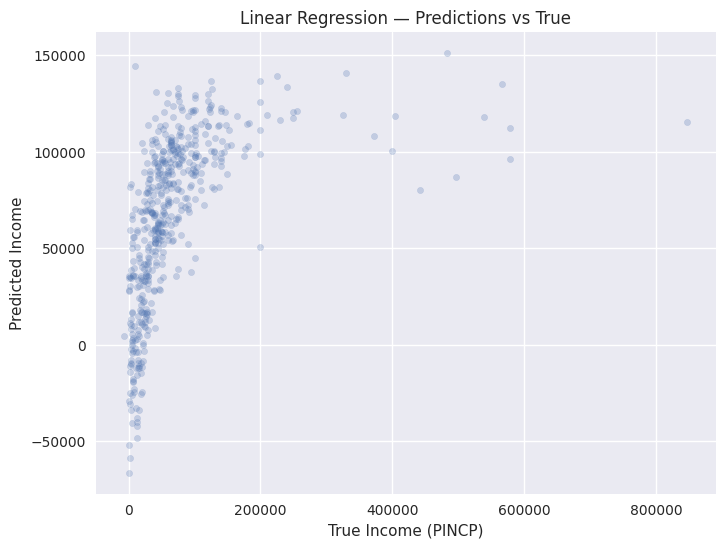

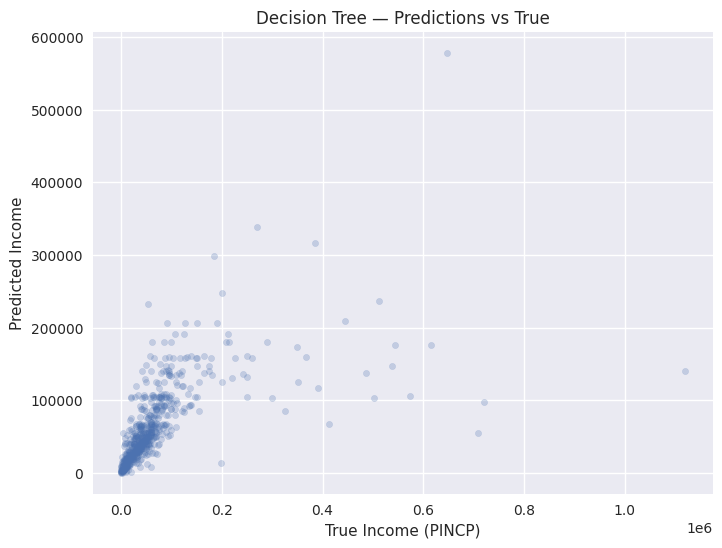

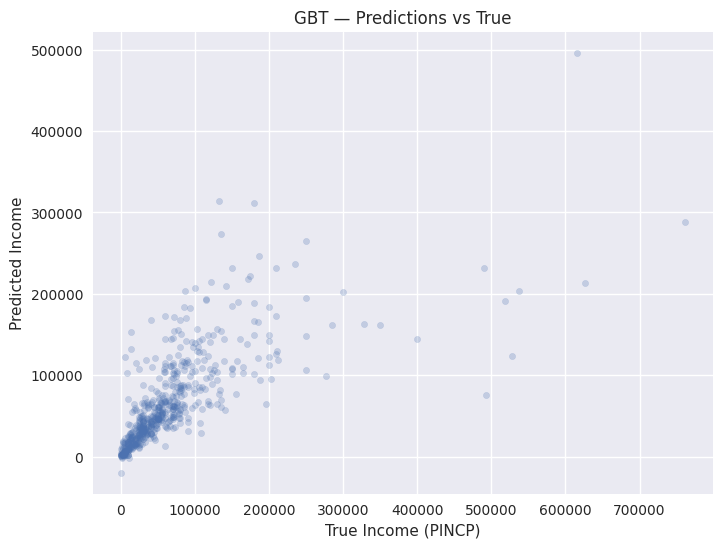

In [10]:
import pyspark.sql.functions as F
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. ВИБІР КОЛОНОК
# ============================================================

cols = [
    "PINCP",   
    "AGEP","WKHP","WKWN","POVPIP",
    "SEX","SCHL","MAR","RAC1P","NATIVITY","ESR","HICOV",
    "HINS1","HINS2","HINS3","HINS4","HINS5","HINS6","HINS7"
]

df = df_demo.select(cols).dropna()

# невелике семплювання
df = df.sample(False, 0.08, seed=42)
print("Rows after sampling:", df.count())

# ============================================================
# 2. КАТЕГОРІАЛЬНІ ОЗНАКИ → ІНДЕКСИ
# ============================================================

cat_cols = [
    "SEX","SCHL","MAR","RAC1P","NATIVITY","ESR","HICOV",
    "HINS1","HINS2","HINS3","HINS4","HINS5","HINS6","HINS7"
]

idx_cols = []
for c in cat_cols:
    idx = c + "_idx"
    df = StringIndexer(inputCol=c, outputCol=idx, handleInvalid="keep") \
            .fit(df).transform(df)
    idx_cols.append(idx)

# ============================================================
# 3. ФІЧІ
# ============================================================

feature_cols = ["AGEP","WKHP","WKWN","POVPIP"] + idx_cols

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_model = assembler.transform(df).select("features", "PINCP")

# TRAIN/TEST
train, test = df_model.randomSplit([0.8, 0.2], seed=42)

# ============================================================
# 4. ФУНКЦІЯ ОЦІНКИ МОДЕЛЕЙ
# ============================================================

def evaluate_on(train_df, test_df, model):
    pred_train = model.transform(train_df)
    pred_test  = model.transform(test_df)

    eval_rmse = RegressionEvaluator(labelCol="PINCP", predictionCol="prediction", metricName="rmse")
    eval_mae  = RegressionEvaluator(labelCol="PINCP", predictionCol="prediction", metricName="mae")
    eval_r2   = RegressionEvaluator(labelCol="PINCP", predictionCol="prediction", metricName="r2")

    return {
        "rmse_train": eval_rmse.evaluate(pred_train),
        "rmse_test":  eval_rmse.evaluate(pred_test),

        "mae_train":  eval_mae.evaluate(pred_train),
        "mae_test":   eval_mae.evaluate(pred_test),

        "r2_train":   eval_r2.evaluate(pred_train),
        "r2_test":    eval_r2.evaluate(pred_test),

        "pred_train": pred_train,
        "pred_test":  pred_test
    }

# ============================================================
# 5. ТРИ МОДЕЛІ
# ============================================================

lr = LinearRegression(featuresCol="features", labelCol="PINCP", maxIter=40)
lr_model = lr.fit(train)
lr_metrics = evaluate_on(train, test, lr_model)

dt = DecisionTreeRegressor(featuresCol="features", labelCol="PINCP",
                           maxDepth=12, maxBins=256)
dt_model = dt.fit(train)
dt_metrics = evaluate_on(train, test, dt_model)

gbt = GBTRegressor(featuresCol="features", labelCol="PINCP",
                   maxIter=40, maxDepth=8, maxBins=256)
gbt_model = gbt.fit(train)
gbt_metrics = evaluate_on(train, test, gbt_model)

# ============================================================
# 6. ТАБЛИЦЯ МЕТРИК
# ============================================================

results = pd.DataFrame([
    ["Linear Regression", lr_metrics["rmse_train"], lr_metrics["rmse_test"], 
     lr_metrics["mae_train"], lr_metrics["mae_test"], lr_metrics["r2_train"], lr_metrics["r2_test"]],

    ["Decision Tree", dt_metrics["rmse_train"], dt_metrics["rmse_test"],
     dt_metrics["mae_train"], dt_metrics["mae_test"], dt_metrics["r2_train"], dt_metrics["r2_test"]],

    ["GBT", gbt_metrics["rmse_train"], gbt_metrics["rmse_test"],
     gbt_metrics["mae_train"], gbt_metrics["mae_test"], gbt_metrics["r2_train"], gbt_metrics["r2_test"]]
],
columns=["Model", "RMSE(train)","RMSE(test)", "MAE(train)","MAE(test)", "R2(train)", "R2(test)"]
)

print(results)

# ============================================================
# 7. ГРАФІКИ (БІЛЬШЕ ТОЧОК!)
# ============================================================

def plot_predictions(pdf, title):
    plt.figure(figsize=(8,6))
    plt.scatter(pdf["PINCP"], pdf["prediction"], alpha=0.25, s=20)
    plt.xlabel("True Income (PINCP)")
    plt.ylabel("Predicted Income")
    plt.title(title)
    plt.grid(True)
    plt.show()

# === збільшено sample до 0.02 (в 10 разів більше точок)
sample_size = 0.02

lr_pdf  = lr_metrics["pred_test"].select("PINCP","prediction").sample(False, sample_size).toPandas()
dt_pdf  = dt_metrics["pred_test"].select("PINCP","prediction").sample(False, sample_size).toPandas()
gbt_pdf = gbt_metrics["pred_test"].select("PINCP","prediction").sample(False, sample_size).toPandas()

plot_predictions(lr_pdf,  "Linear Regression — Predictions vs True")
plot_predictions(dt_pdf,  "Decision Tree — Predictions vs True")
plot_predictions(gbt_pdf, "GBT — Predictions vs True")
